In [1]:
#Bibliotecas
import pandas as pd
import polars as pl
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import re
import math

In [34]:
caminho_arquivo = "tratados_3det/photon/photon1E15"

def processar_arquivo(nome_arquivo):
    # Listas para armazenar as detecções por tipo de partícula e por detector
    positrons = {"TRIG1": [], "TRIG2": [], "TRIG3": []}
    electrons = {"TRIG1": [], "TRIG2": [], "TRIG3": []}
    muons_plus = {"TRIG1": [], "TRIG2": [], "TRIG3": []}
    muons_minus = {"TRIG1": [], "TRIG2": [], "TRIG3": []}

    # Listas para totais por detector
    total_por_detector = {"TRIG1": [], "TRIG2": [], "TRIG3": []}

    # Listas para somas de elétrons+pósitrons e múons+/-
    soma_electrons_positrons = {"TRIG1": [], "TRIG2": [], "TRIG3": []}
    soma_muons_plus_minus = {"TRIG1": [], "TRIG2": [], "TRIG3": []}

    # Abrir e ler o arquivo
    with open(nome_arquivo, 'r') as arquivo:
        for linha in arquivo:
            linha = linha.strip()

            # Processar apenas linhas que começam com TRIG
            if linha.startswith("TRIG"):
                partes = linha.split()
                detector = partes[0]  # TRIG1, TRIG2, TRIG3

                # Valores das partículas
                pos = int(partes[1])  # Pósitrons
                ele = int(partes[2])  # Elétrons
                mu_p = int(partes[3])  # Múons+
                mu_m = int(partes[4])  # Múons-

                # Adicionar os valores às listas correspondentes
                positrons[detector].append(pos)
                electrons[detector].append(ele)
                muons_plus[detector].append(mu_p)
                muons_minus[detector].append(mu_m)

                # Calcular totais
                total = pos + ele + mu_p + mu_m
                total_por_detector[detector].append(total)

                # Calcular somas
                soma_electrons_positrons[detector].append(pos + ele)
                soma_muons_plus_minus[detector].append(mu_p + mu_m)

    # Retornar os dados processados
    return {
        "positrons": positrons,
        "electrons": electrons,
        "muons_plus": muons_plus,
        "muons_minus": muons_minus,
        "total_por_detector": total_por_detector,
        "soma_electrons_positrons": soma_electrons_positrons,
        "soma_muons_plus_minus": soma_muons_plus_minus
    }

# Função principal
def main():
    
    dados = processar_arquivo(caminho_arquivo)

    # Alguns testes
    print("Detecções de pósitrons no TRIG1:", dados["positrons"]["TRIG1"])
    print("Total de partículas no TRIG2:", dados["total_por_detector"]["TRIG2"])
    print("Soma de elétrons e pósitrons no TRIG3:", dados["soma_electrons_positrons"]["TRIG3"])

    return dados



# Executar o programa
if __name__ == "__main__":
    dados_processados = main()


Detecções de pósitrons no TRIG1: [0, 0, 0, 0, 0, 15, 0, 0, 3, 2, 0, 33, 0, 5, 0, 3, 68, 6, 15, 1, 0, 3, 0, 23, 0, 0, 29, 0, 0, 9, 0, 0, 13, 0, 11, 0, 6, 6, 7, 0, 3, 11, 8, 18, 14, 35, 0, 22, 0, 1, 0, 0, 7, 4, 26, 0, 28, 0, 0, 4, 4, 0, 6, 3, 0, 12, 0, 21, 0, 13, 0, 0, 13, 0, 0, 14, 0, 0, 0, 0, 0, 0, 2, 0, 0, 22, 0, 0, 0, 8, 0, 35, 2, 14, 8, 144, 0, 0, 57, 18, 0, 19, 0, 0, 1, 2, 0, 25, 70, 16, 0, 1, 4, 3, 0, 21, 0, 0, 2, 0, 0, 1, 10, 38, 57, 6, 42, 52, 0, 12, 1, 0, 21, 21, 34, 4, 0, 0, 0, 0, 0, 0, 124, 0, 0, 4, 1, 0, 0, 3, 29, 0, 0, 13, 12, 1, 33, 40, 0, 0, 0, 0, 0, 21, 2, 35, 1, 5, 0, 1, 28, 25, 0, 16, 0, 1, 3, 4, 0, 3, 104, 0, 5, 28, 0, 0, 0, 18, 0, 12, 0, 3, 0, 0, 211, 33, 2, 3, 5, 0, 7, 23, 18, 0, 8, 10, 1, 9, 3, 109, 2, 4, 4, 0, 1, 6, 4, 5, 0, 29, 22, 10, 0, 57, 0, 0, 0, 0, 24, 22, 1, 1, 7, 0, 11, 0, 11, 5, 6, 0, 12, 27, 0, 70, 0, 0, 0, 25, 51, 0, 0, 0, 1, 0, 5, 15, 46, 0, 2, 9, 0, 15, 1, 43, 4, 0, 5, 7, 1, 0, 0, 16, 4, 11, 16, 3, 21, 0, 0, 9, 0, 0, 1, 2, 0, 25, 16, 2, 123, 0, 0, 0,

In [35]:
# Posição dos tanques
x1 = [0,346]
x2 = [-400,-346]
x3 = [400,-346]

# Distância dos tanques em relação ao centro
r1 = (x1[0]**2+x1[1]**2)**0.5
r2 = (x2[0]**2+x2[1]**2)**0.5
r3 = (x3[0]**2+x3[1]**2)**0.5


# Total de partículas em cada tanque
trig1 = dados_processados['total_por_detector']['TRIG1']
trig2 = dados_processados['total_por_detector']['TRIG2']
trig3 = dados_processados['total_por_detector']['TRIG3']

print(trig1,'\n',
      trig2,'\n',
      trig3)

[2, 1, 0, 0, 0, 30, 0, 0, 5, 8, 0, 74, 0, 13, 0, 10, 169, 14, 32, 3, 0, 13, 0, 57, 0, 0, 65, 0, 0, 18, 0, 0, 33, 0, 23, 2, 12, 22, 15, 0, 8, 23, 20, 49, 35, 77, 0, 52, 0, 1, 0, 0, 15, 11, 70, 0, 77, 0, 0, 10, 7, 0, 16, 5, 0, 36, 0, 56, 0, 35, 0, 0, 39, 0, 0, 29, 0, 0, 0, 0, 0, 0, 4, 0, 0, 43, 0, 0, 0, 21, 1, 74, 4, 36, 14, 364, 0, 0, 119, 31, 0, 49, 0, 1, 2, 3, 0, 73, 152, 45, 0, 3, 12, 9, 0, 42, 0, 0, 4, 2, 0, 4, 25, 106, 148, 16, 94, 136, 0, 27, 3, 0, 48, 53, 87, 9, 0, 0, 0, 1, 0, 1, 273, 0, 0, 7, 1, 0, 0, 5, 64, 0, 0, 39, 30, 3, 71, 86, 0, 0, 0, 0, 0, 54, 3, 87, 2, 11, 0, 4, 60, 54, 1, 48, 0, 4, 5, 12, 0, 4, 239, 1, 11, 65, 0, 0, 0, 35, 0, 33, 0, 15, 0, 0, 503, 91, 3, 5, 11, 0, 11, 54, 36, 0, 18, 25, 4, 21, 5, 277, 4, 5, 12, 0, 1, 12, 7, 14, 0, 64, 55, 24, 0, 130, 0, 4, 0, 0, 77, 56, 1, 5, 12, 0, 33, 3, 21, 8, 16, 0, 30, 63, 1, 177, 0, 0, 0, 61, 135, 0, 0, 2, 2, 0, 15, 38, 116, 0, 4, 33, 0, 40, 1, 106, 6, 0, 11, 16, 2, 0, 0, 38, 9, 24, 50, 4, 51, 0, 0, 26, 0, 0, 6, 3, 0, 48, 29, 3, 

In [36]:
x_b = []
y_b = []

for i in range(len(trig1)):
        numerator = (trig1[i]*x1[0]+trig2[i]*x2[0]+trig3[i]*x3[0])
        demoninator = (trig1[i]+trig2[i]+trig3[i])
        numerator1 = (trig1[i]*x1[1]+trig2[i]*x2[1]+trig3[i]*x3[1])

        if demoninator == 0:
                x_b.append(0)
                y_b.append(0)
        else:
                x_b.append(numerator/demoninator)
                y_b.append(numerator1/demoninator)


In [37]:
data = {
    'x_b':x_b,
    'y_b':y_b,
    'trig1':trig1,
    'trig2':trig2,
    'trig3':trig3
}

df = pl.DataFrame(data, strict=False)

df = df.with_columns(
    [
        ((df['x_b']**2+df['y_b']**2)**0.5).alias('r_b'),
        (pl.col('trig1')/(math.pi*65**2)).alias('rho1'),
        (pl.col('trig2')/(math.pi*65**2)).alias('rho2'),
        (pl.col('trig3')/(math.pi*65**2)).alias('rho3')
    ]
)

df = df.with_columns(
    [
        (((x1[0]-df['x_b'])**2 + (x1[1]-df['y_b'])**2)**0.5).alias('r1_b'),
        (((x2[0]-df['x_b'])**2 + (x2[1]-df['y_b'])**2)**0.5).alias('r2_b'),
        (((x3[0]-df['x_b'])**2 + (x3[1]-df['y_b'])**2)**0.5).alias('r3_b'),
    ]
)



df2 = df.mean()
df2

x_b,y_b,trig1,trig2,trig3,r_b,rho1,rho2,rho3,r1_b,r2_b,r3_b
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
3.128454,-47.219813,27.628,18.866,18.993,96.498693,0.002081,0.001421,0.001431,402.78158,511.946233,506.666791


In [38]:
rho = [
    df2['rho1'][0],
    df2['rho2'][0],
    df2['rho3'][0]
]

r_b = [
    df2['r1_b'][0],
    df2['r2_b'][0],
    df2['r3_b'][0]
]
print(rho,r_b)


data2 = {
    'rho':rho,
    'r_b':r_b
}

df3 = pl.DataFrame(data2)
#df3.write_csv('bary_dat/' + arquivo + '_bary.csv', separator= '\t', has_header= False)

[0.0020814829669788797, 0.0014213572337854188, 0.0014309253652754405] [402.7815795354589, 511.9462334550443, 506.66679140038065]


In [39]:
def formatar_string(s):

    nome_arquivo = s.split('/')[-1]
   
    match = re.match(r'([a-zA-Z]+)([0-9]+(?:\.[0-9]+)?[Ee][0-9]+)', nome_arquivo)

    if match:
        
        palavra = match.group(1).capitalize()
        numero = match.group(2)

        return f'{palavra} {numero}'
    else:
        return nome_arquivo

name = formatar_string(caminho_arquivo)
name

'Photon 1E15'

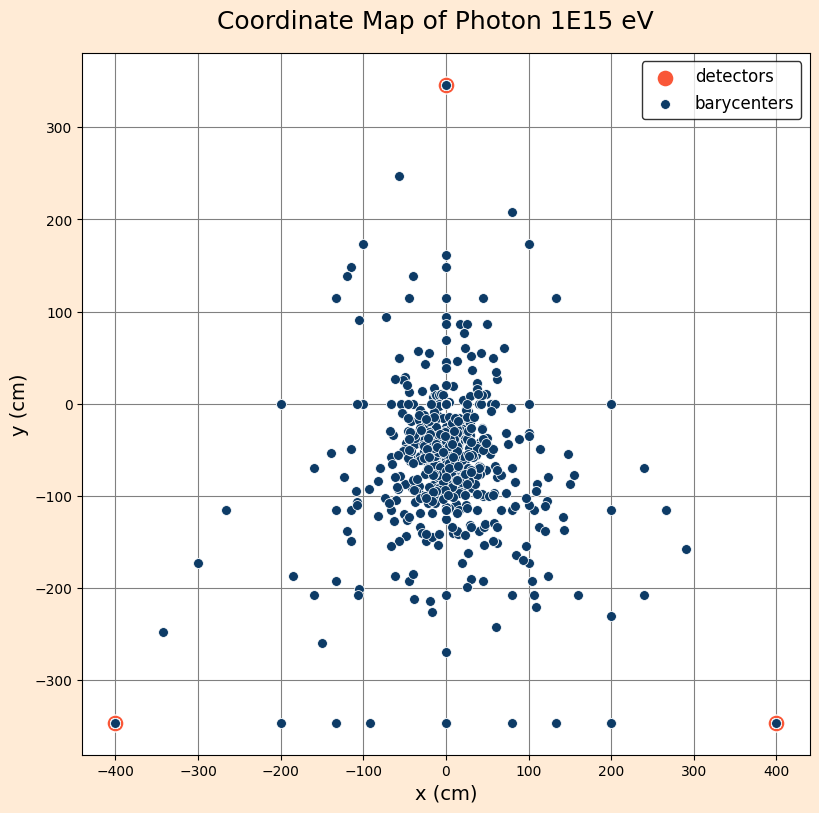

In [40]:
fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Coordinate Map of ' + str(name) + ' eV', size = 18)
fig.tight_layout()
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-')
ax.xaxis.grid(color='gray', linestyle='-')

sns.scatterplot(x = [x1[0],x2[0],x3[0]], y = [x1[1],x2[1],x3[1]], ax = ax, color = '#F95738', s = 150)
sns.scatterplot(x = df['x_b'], y = df['y_b'], ax = ax, color = '#0D3B66',s = 50)

ax.set_xlabel('x (cm)', size = 14)
ax.set_ylabel('y (cm)', size = 14)


ax.legend(['detectors', 'barycenters'], edgecolor = 'black', fontsize = 12, loc = 1)

#plt.savefig('plots/map_' + str(arquivo) + '.png',bbox_inches = 'tight')

In [29]:
# Reconstrução da energia

E_real = [1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]
r0 = 7800

# Parâmetros fóton

k_photon = 6.59E-17 #+- 3.82E-17
p_photon = 1.39 #+- 0.02
c_photon = [1975,5697,1.539E4,4.969E4,1.368E5,4.35E5]
s_photon = [1.506,1.303,1.364,1.334,1.307,1.304]
E_photon = []


for i in range(len(c_photon)):
    E = (c_photon[i]/k_photon)**(1/p_photon)
    E_photon.append(E)
    #N = ((c_photon[i])/((r0**(s_photon[i]))))*(1000**((s_photon[i]-1))/(s_photon[i]-1))*math.pi*1000**2
    #N_photon.append(N)
    #print('{:e}'.format(E_photon[i]))


# Parâmetros próton

k_proton = 3.02E-14
p_proton = 1.21
c_proton = [2894,6269,1.609E4,4.776E4,1.028E5,2.606E5]
s_proton = [1.481,1.348,1.407,1.317,1.326,1.285]
E_proton = []

for i in range(len(c_photon)):
    E = (c_proton[i]/k_proton)**(1/p_proton)
    E_proton.append(E)
    #print('{:e}'.format(E_proton[i]))

# Parâmetros ferro

k_iron = 2.42E-17
p_iron = 1.39
c_iron = [293.8,3226,6020,1.778E4,5.223E4,1.058E5]
s_iron = [2.033,2.097,1.778,1.645,1.606,1.431]
E_iron = []

for i in range(len(c_iron)):
    E = (c_iron[i]/k_iron)**(1/p_iron)
    E_iron.append(E)
    #print('{:e}'.format(E_iron[i]))


data = {
    'E':E_real,
    'E_photon':E_photon,
    'E_proton':E_proton,
    'E_iron':E_iron
}

df = pl.DataFrame(data)
df

E,E_photon,E_proton,E_iron
f64,f64,f64,f64
1.0000e14,1.0280e14,1.0822e14,5.3662e13
2.1500e14,2.2029e14,2.0499e14,3.0082e14
4.6400e14,4.5029e14,4.4673e14,4.7122e14
1.0000e15,1.0464e15,1.0979e15,1.0271e15
2.1500e15,2.1683e15,2.0687e15,2.2299e15
4.6400e15,4.9838e15,4.4623e15,3.7053e15


[Text(0.5, 1.0, 'Energy relative diviation $\\Delta$E/E')]

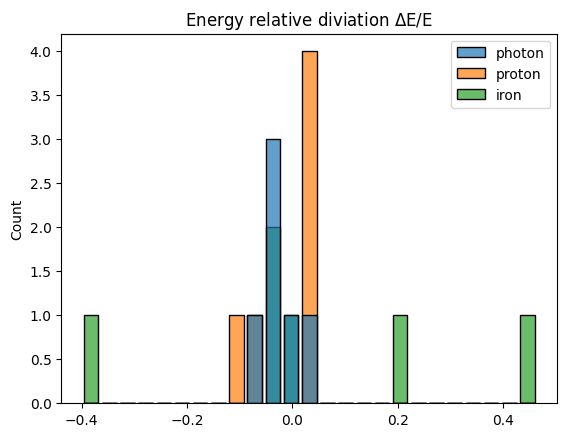

In [33]:
DeltaE_photon = []
DeltaE_proton = []
DeltaE_iron = []

for i in range(len(E_real)):
    aux = (E_real[i] - E_photon[i])/E_real[i]
    aux2 = (E_real[i] - E_proton[i])/E_real[i]
    aux3 = (E_real[i] - E_iron[i])/E_real[i]
    DeltaE_photon.append(aux)
    DeltaE_proton.append(aux2)
    DeltaE_iron.append(aux3)

data = {
    'photon':DeltaE_photon,
    'proton':DeltaE_proton,
    'iron':DeltaE_iron
}

sns.histplot(data=data, bins= 25, shrink=0.8, alpha = 0.7).set(title = 'Energy relative diviation $\Delta$E/E')